## 1. Explicación conceptual: estructura y utilidad de una red neuronal convolutiva

### ¿Qué es una red neuronal convolutiva?

Una Red Neuronal Convolutiva (CNN) es un tipo de red neuronal especialmente diseñada para trabajar con datos que poseen una estructura espacial, como las imágenes.

A diferencia de una red neuronal densa tradicional, una CNN no analiza todos los píxeles de una imagen de manera independiente desde el comienzo. En su lugar, utiliza filtros que recorren pequeñas regiones de la imagen para identificar características importantes.

Durante las primeras etapas, una CNN puede aprender características simples, como bordes, líneas o formas. A medida que la información avanza por la red, estas características pueden combinarse para reconocer patrones más complejos.

En esta prueba se utilizará una CNN para clasificar imágenes de dígitos escritos a mano del 0 al 9.

---

### Principales capas de una CNN

#### 1. Capa de convolución

La capa de convolución, implementada en Keras mediante `Conv2D`, utiliza pequeños filtros o kernels que recorren la imagen.

Estos filtros permiten detectar características relevantes, como bordes, líneas, curvas y otras formas presentes en los píxeles.

El resultado de este proceso genera nuevos mapas de características que representan los patrones encontrados por la red.

#### 2. Capa de pooling

La capa de pooling permite reducir las dimensiones de los mapas de características obtenidos mediante la convolución.

Una técnica común es `MaxPooling2D`, que selecciona el valor máximo dentro de pequeñas regiones de la imagen.

Esto permite disminuir la cantidad de información que debe procesar la red, conservando las características más relevantes y reduciendo el costo computacional.

#### 3. Capa Flatten

Después de las operaciones de convolución y pooling, los datos continúan organizados en estructuras multidimensionales.

La capa `Flatten` transforma estos datos en un vector de una sola dimensión, permitiendo conectarlos con las capas densas de la red neuronal.

Esta capa no realiza una clasificación, sino que adapta la estructura de los datos para que puedan ser procesados por las siguientes capas.

#### 4. Capa densa

Las capas `Dense` utilizan las características obtenidas anteriormente para realizar la clasificación final.

En este problema, la última capa deberá distinguir entre 10 clases, correspondientes a los dígitos:

`0, 1, 2, 3, 4, 5, 6, 7, 8 y 9`.

Por esta razón, la capa de salida tendrá 10 neuronas, donde cada una estará asociada a una posible clase.

---

### Funcionamiento general de una CNN

El funcionamiento de una red neuronal convolutiva puede resumirse de la siguiente manera:

1. La imagen es ingresada a la red como una matriz de píxeles.
2. Las capas de convolución aplican filtros para detectar características relevantes.
3. Las capas de pooling reducen las dimensiones de los mapas de características.
4. `Flatten` transforma la información obtenida en un vector.
5. Las capas densas procesan las características extraídas.
6. La capa de salida determina a qué clase pertenece la imagen.

Durante el entrenamiento, la red compara sus predicciones con las respuestas reales y ajusta sus parámetros con el objetivo de disminuir el error y mejorar progresivamente su capacidad de clasificación.

---

### Aplicaciones prácticas

Las redes neuronales convolutivas son especialmente útiles en problemas relacionados con imágenes y visión computacional. Algunas aplicaciones prácticas son:

- Reconocimiento de dígitos escritos a mano.
- Clasificación de imágenes.
- Reconocimiento de objetos.
- Análisis de imágenes médicas.
- Reconocimiento facial.
- Identificación de patrones visuales en sistemas industriales.

En el caso de esta prueba, la CNN será utilizada para reconocer automáticamente imágenes pequeñas de dígitos escritos a mano y clasificarlas entre las categorías del `0` al `9`.

---

### Esquema general de la CNN

La estructura general que se utilizará en este problema puede representarse de la siguiente manera:

**Imagen de entrada (8 × 8 × 1)**  
↓  
**Conv2D**  
Extracción de características  
↓  
**MaxPooling2D**  
Reducción de dimensiones  
↓  
**Flatten**  
Conversión a vector  
↓  
**Dense**  
Procesamiento de las características  
↓  
**Capa de salida**  
Clasificación entre 10 clases  
↓  
**Predicción: dígito 0 - 9**

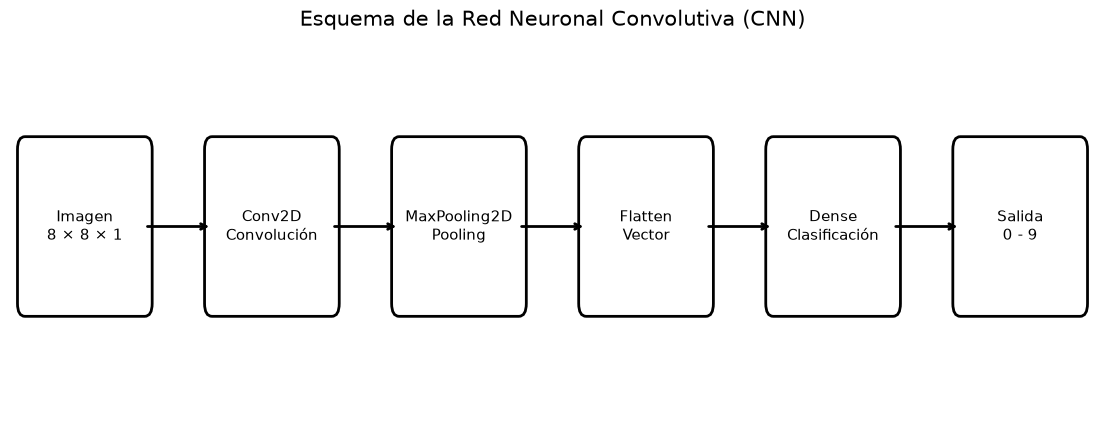

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 5))

posiciones = [
    (0.5, 2, "Imagen\n8 × 8 × 1"),
    (3, 2, "Conv2D\nConvolución"),
    (5.5, 2, "MaxPooling2D\nPooling"),
    (8, 2, "Flatten\nVector"),
    (10.5, 2, "Dense\nClasificación"),
    (13, 2, "Salida\n0 - 9")]

for x, y, texto in posiciones:
    caja = FancyBboxPatch(
        (x - 0.8, y - 0.6),
        1.6,
        1.2,
        boxstyle="round,pad=0.1",
        fill=False,
        linewidth=2)
    
    ax.add_patch(caja)
    ax.text(
        x,
        y,
        texto,
        ha="center",
        va="center",
        fontsize=11)


for i in range(len(posiciones) - 1):
    x1 = posiciones[i][0] + 0.8
    x2 = posiciones[i + 1][0] - 0.8
    
    ax.annotate(
        "",
        xy=(x2, 2),
        xytext=(x1, 2),
        arrowprops=dict(arrowstyle="->", linewidth=2))

ax.set_title(
    "Esquema de la Red Neuronal Convolutiva (CNN)",
    fontsize=15)


ax.set_xlim(-0.5, 14)
ax.set_ylim(0.5, 3.5)

ax.axis("off")

plt.show()

#### Interpretación del esquema

El esquema representa el flujo de información dentro de la red neuronal convolutiva utilizada para la clasificación de dígitos.

La imagen de entrada posee dimensiones de 8 × 8 píxeles y un canal, representado mediante el formato `(8, 8, 1)`. Posteriormente, la capa `Conv2D` aplica filtros para extraer características visuales de la imagen.

La capa `MaxPooling2D` reduce las dimensiones de los mapas de características conservando información relevante. Luego, `Flatten` transforma los datos obtenidos en un vector que puede ser procesado por las capas densas.

Finalmente, la red utiliza una capa de salida para realizar la clasificación entre las 10 posibles clases, correspondientes a los dígitos del `0` al `9`.

## 2. Implementación del modelo CNN para reconocimiento de imágenes

### Carga y exploración del dataset

Para implementar la red neuronal convolutiva se utilizará el dataset de dígitos proporcionado para la prueba.

Cada observación representa una imagen de un dígito escrito a mano. Las imágenes poseen dimensiones de **8 × 8 píxeles**, por lo que cada registro contiene **64 valores de píxeles**.

Además, el dataset contiene una variable denominada `label`, que identifica el dígito representado en cada imagen, con valores entre `0` y `9`.

Antes de construir la CNN, se realizará una exploración inicial para conocer las dimensiones, estructura y distribución de las clases presentes en los datos.

In [2]:
import pandas as pd

df = pd.read_excel("07. Apoyo desafío - digitos_mnist_simple.xlsx")

df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [3]:

print("Dimensiones del dataset:", df.shape)

print("\nValores nulos:", df.isnull().sum().sum())

print("\nClases disponibles:")
print(sorted(df["label"].unique()))

print("\nCantidad de imágenes por clase:")
print(df["label"].value_counts().sort_index())

Dimensiones del dataset: (1797, 65)

Valores nulos: 0

Clases disponibles:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Cantidad de imágenes por clase:
label
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


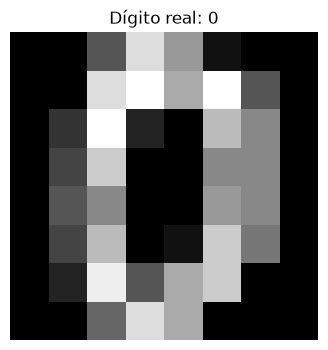

In [4]:
import matplotlib.pyplot as plt

imagen = df.drop("label", axis=1).iloc[0].values

imagen = imagen.reshape(8, 8)

plt.figure(figsize=(4, 4))
plt.imshow(imagen, cmap="gray")
plt.title(f"Dígito real: {df['label'].iloc[0]}")
plt.axis("off")
plt.show()

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

X = df.drop("label", axis=1).values
y = df["label"].values

print("Forma original de X:", X.shape)
print("Forma original de y:", y.shape)

print("\nValor mínimo de los píxeles:", X.min())
print("Valor máximo de los píxeles:", X.max())

Forma original de X: (1797, 64)
Forma original de y: (1797,)

Valor mínimo de los píxeles: 0.0
Valor máximo de los píxeles: 16.0


In [6]:
# Normalizamos los valores de los píxeles al rango 0 - 1
X = X.astype("float32") / 16.0

print("Valor mínimo después de normalizar:", X.min())
print("Valor máximo después de normalizar:", X.max())

Valor mínimo después de normalizar: 0.0
Valor máximo después de normalizar: 1.0


In [7]:

X = X.reshape(-1, 8, 8, 1)

print("Nueva forma de X:", X.shape)

Nueva forma de X: (1797, 8, 8, 1)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1437, 8, 8, 1)
X_test : (360, 8, 8, 1)
y_train: (1437,)
y_test : (360,)


### Construcción del modelo CNN

Una vez preprocesados los datos, se construye una Red Neuronal Convolutiva utilizando Keras.

El modelo utiliza capas `Conv2D` para extraer características de las imágenes y capas `MaxPooling2D` para reducir progresivamente sus dimensiones. Posteriormente, la capa `Flatten` transforma los mapas de características en un vector y las capas densas realizan la clasificación.

Debido a que el problema considera 10 clases posibles, correspondientes a los dígitos del 0 al 9, la capa de salida contiene 10 neuronas y utiliza la función de activación `softmax`.

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


modelo = Sequential([
 
    Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        input_shape=(8, 8, 1)),
    
    
    MaxPooling2D(pool_size=(2, 2)),
    
   
    Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"),
    
    
    MaxPooling2D(pool_size=(2, 2)),
   
    Flatten(),
    
    Dense(64, activation="relu"),
    
    Dense(10, activation="softmax")])

modelo.summary()

c:\Users\giany\anaconda3\envs\CURSO_CIENCIA_DE_DATOS\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,914 (140.29 KB)

 Trainable params: 35,914 (140.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

print("Modelo compilado correctamente.")

Modelo compilado correctamente.


### Entrenamiento del modelo CNN

El modelo se entrena utilizando los datos previamente normalizados y reorganizados en el formato requerido por la red convolutiva.

Para este primer modelo se utilizarán **15 épocas** y un `batch_size` de **32**. Además, se reservará un 20% de los datos de entrenamiento para validación mediante `validation_split=0.2`.

La validación permitirá observar el comportamiento del modelo sobre datos que no son utilizados directamente para actualizar sus parámetros durante el entrenamiento. De esta manera, será posible comparar las métricas de entrenamiento y validación, principalmente `accuracy` y `loss`.

In [11]:
historial = modelo.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1)

Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3229 - loss: 2.1461 - val_accuracy: 0.5069 - val_loss: 1.9275
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6728 - loss: 1.4076 - val_accuracy: 0.7153 - val_loss: 0.9648
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8616 - loss: 0.6264 - val_accuracy: 0.8958 - val_loss: 0.4603
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9199 - loss: 0.3220 - val_accuracy: 0.9236 - val_loss: 0.2822
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9539 - loss: 0.2098 - val_accuracy: 0.9375 - val_loss: 0.2097
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9669 - loss: 0.1443 - val_accuracy: 0.9236 - val_loss: 0.2387
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9678 - loss: 0.1328 - val_accuracy: 0.9549 - val_loss: 0.1574
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9809 - loss: 0.0982 - val_accuracy: 0.9479 - val_loss:

### Evolución del entrenamiento

Para analizar el comportamiento de la CNN durante el entrenamiento, se representan gráficamente las métricas de `accuracy` y `loss` obtenidas tanto para el conjunto de entrenamiento como para el conjunto de validación.

Estos gráficos permiten observar el aprendizaje del modelo a través de las épocas y detectar posibles diferencias entre su desempeño en entrenamiento y validación.

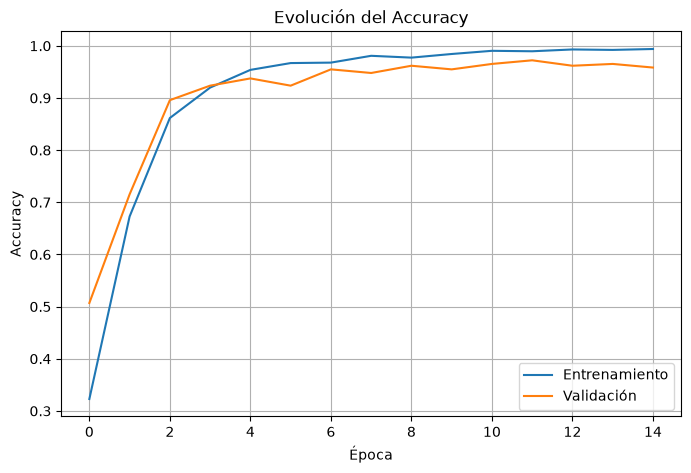

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(historial.history["accuracy"], label="Entrenamiento")
plt.plot(historial.history["val_accuracy"], label="Validación")

plt.title("Evolución del Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

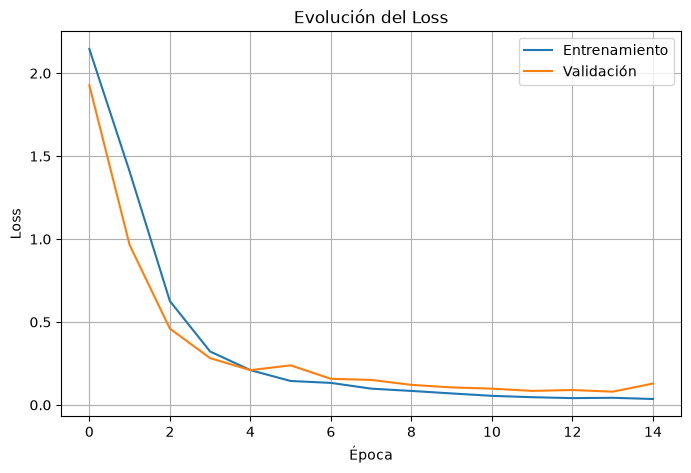

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(historial.history["loss"], label="Entrenamiento")
plt.plot(historial.history["val_loss"], label="Validación")

plt.title("Evolución del Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

### Evaluación del modelo con el conjunto de prueba

Una vez finalizado el entrenamiento, el modelo se evalúa utilizando el conjunto de prueba (`X_test`, `y_test`).

Estos datos no fueron utilizados para actualizar los parámetros de la red durante el entrenamiento, por lo que permiten obtener una estimación más objetiva de la capacidad del modelo para clasificar imágenes no vistas previamente.

In [14]:
loss_test, accuracy_test = modelo.evaluate(
    X_test,
    y_test,
    verbose=0)

print(f"Loss en prueba: {loss_test:.4f}")
print(f"Accuracy en prueba: {accuracy_test:.4f}")
print(f"Accuracy en prueba: {accuracy_test * 100:.2f}%")

Loss en prueba: 0.1034
Accuracy en prueba: 0.9639
Accuracy en prueba: 96.39%


### Matriz de confusión

Además de las métricas de `accuracy` y `loss`, se utiliza una matriz de confusión para analizar con mayor detalle el desempeño del modelo.

Esta matriz permite comparar las clases reales con las clases predichas por la CNN. Los valores ubicados en la diagonal principal corresponden a predicciones correctas, mientras que los valores fuera de la diagonal representan errores de clasificación entre los distintos dígitos.

In [15]:
import numpy as np

predicciones = modelo.predict(X_test, verbose=0)

y_pred = np.argmax(predicciones, axis=1)

print("Primeras 10 clases reales:")
print(y_test[:10])

print("\nPrimeras 10 clases predichas:")
print(y_pred[:10])

Primeras 10 clases reales:
[5 2 8 1 7 2 6 2 6 5]

Primeras 10 clases predichas:
[5 2 1 1 7 2 6 2 6 5]


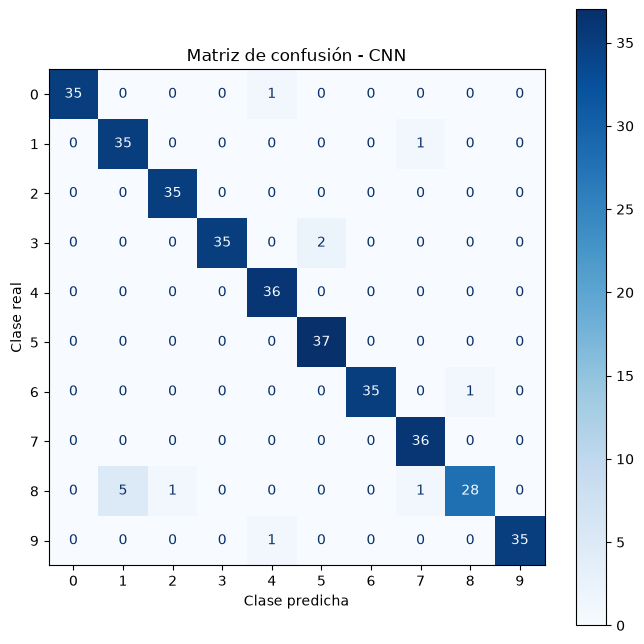

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

matriz_confusion = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=range(10))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Matriz de confusión - CNN")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()

### Interpretación de los resultados

El modelo CNN obtuvo un **accuracy de 96,39 %** sobre el conjunto de prueba, con un valor de `loss` de **0,1034**. Estos resultados indican que la red logró aprender adecuadamente las características visuales necesarias para distinguir los dígitos escritos a mano.

La matriz de confusión muestra una alta concentración de valores en la diagonal principal, lo que evidencia que la mayoría de las imágenes fueron clasificadas correctamente. De las 360 imágenes utilizadas para prueba, el modelo clasificó correctamente 347.

El dígito que presentó mayor dificultad fue el **8**. De los 35 ejemplos reales de esta clase, 28 fueron reconocidos correctamente, mientras que 5 fueron clasificados como 1, uno como 2 y uno como 7. También se observaron algunos errores aislados entre otras clases, como la confusión del dígito 3 con el 5.

En términos generales, el modelo presenta un buen desempeño y una alta capacidad de clasificación. Sin embargo, durante las últimas épocas del entrenamiento se observa que el desempeño sobre los datos de entrenamiento continúa mejorando, mientras que las métricas de validación presentan algunas fluctuaciones. Esto sugiere la posibilidad de un leve sobreajuste, aspecto que será abordado posteriormente mediante técnicas de regularización y optimización.

## 3. Evaluación y optimización del modelo

El modelo CNN inicial obtuvo un **accuracy de 96,39 %** sobre el conjunto de prueba. Aunque este resultado es satisfactorio, durante las últimas épocas se observaron diferencias entre las métricas de entrenamiento y validación, lo que puede indicar un leve sobreajuste.

Con el objetivo de mejorar la capacidad de generalización del modelo, se aplicarán técnicas de ajuste de hiperparámetros y regularización.

### Técnicas de mejora utilizadas

**1. Ajuste de hiperparámetros**

Se modificará el proceso de entrenamiento aumentando el número máximo de épocas y ajustando el tamaño del `batch_size`.

El número de épocas determina cuántas veces el modelo puede recorrer los datos de entrenamiento, mientras que el `batch_size` determina la cantidad de observaciones utilizadas antes de realizar una actualización de los parámetros.

En lugar de utilizar obligatoriamente todas las épocas definidas, el entrenamiento será controlado mediante `EarlyStopping`.

**2. Dropout**

Se incorporará una capa `Dropout` como técnica de regularización. Durante el entrenamiento, esta técnica desactiva aleatoriamente una proporción de las neuronas, reduciendo la dependencia excesiva entre ellas y ayudando a disminuir el riesgo de sobreajuste.

**3. EarlyStopping**

Se utilizará `EarlyStopping` para supervisar el comportamiento de `val_loss`. Si la pérdida de validación deja de mejorar durante varias épocas consecutivas, el entrenamiento se detendrá automáticamente.

Además, mediante `restore_best_weights=True`, el modelo recuperará los pesos correspondientes a la época que presentó el mejor desempeño de validación.

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

modelo_optimizado = Sequential([
    
    Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        input_shape=(8, 8, 1)),
    
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"),
    
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    
    Dense(64, activation="relu"),
    
  
    Dropout(0.30),
    
    Dense(10, activation="softmax")])

modelo_optimizado.summary()

c:\Users\giany\anaconda3\envs\CURSO_CIENCIA_DE_DATOS\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,914 (140.29 KB)

 Trainable params: 35,914 (140.29 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
modelo_optimizado.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True)

print("Modelo optimizado compilado correctamente.")

Modelo optimizado compilado correctamente.


In [19]:
historial_optimizado = modelo_optimizado.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3621 - loss: 2.0108 - val_accuracy: 0.6771 - val_loss: 1.4867
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7302 - loss: 0.9851 - val_accuracy: 0.8924 - val_loss: 0.5013
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8712 - loss: 0.4755 - val_accuracy: 0.9236 - val_loss: 0.3062
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9252 - loss: 0.2744 - val_accuracy: 0.9549 - val_loss: 0.2019
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9339 - loss: 0.2305 - val_accuracy: 0.9688 - val_loss: 0.1727
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9478 - loss: 0.1826 - val_accuracy: 0.9514 - val_loss: 0.1553
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9547 - loss: 0.1576 - val_accuracy: 0.9653 - val_loss: 0.1388
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9643 - loss: 0.1197 - val_accuracy: 0.9618 - val_l

In [20]:
print(
    "Número de épocas ejecutadas:",
    len(historial_optimizado.history["loss"]))

Número de épocas ejecutadas: 14


In [21]:
loss_optimizado, accuracy_optimizado = modelo_optimizado.evaluate(
    X_test,
    y_test,
    verbose=0)

print(f"Loss modelo optimizado: {loss_optimizado:.4f}")
print(f"Accuracy modelo optimizado: {accuracy_optimizado:.4f}")
print(f"Accuracy modelo optimizado: {accuracy_optimizado * 100:.2f}%")

Loss modelo optimizado: 0.0902
Accuracy modelo optimizado: 0.9722
Accuracy modelo optimizado: 97.22%


In [22]:
import pandas as pd

comparacion = pd.DataFrame({
    "Modelo": ["CNN inicial", "CNN optimizada"],
    "Accuracy": [accuracy_test, accuracy_optimizado],
    "Loss": [loss_test, loss_optimizado]})

comparacion["Accuracy (%)"] = comparacion["Accuracy"] * 100

comparacion[["Modelo", "Accuracy (%)", "Loss"]]

,Modelo,Accuracy (%),Loss
0,CNN inicial,96.388888,0.103425
1,CNN optimizada,97.222221,0.090238


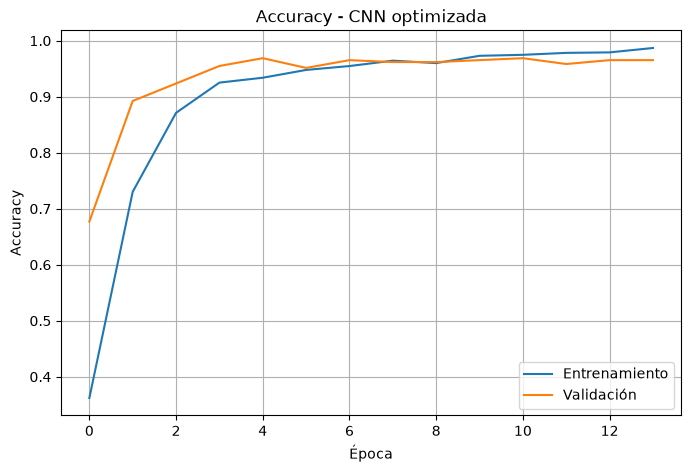

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    historial_optimizado.history["accuracy"],
    label="Entrenamiento")

plt.plot(
    historial_optimizado.history["val_accuracy"],
    label="Validación")

plt.title("Accuracy - CNN optimizada")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

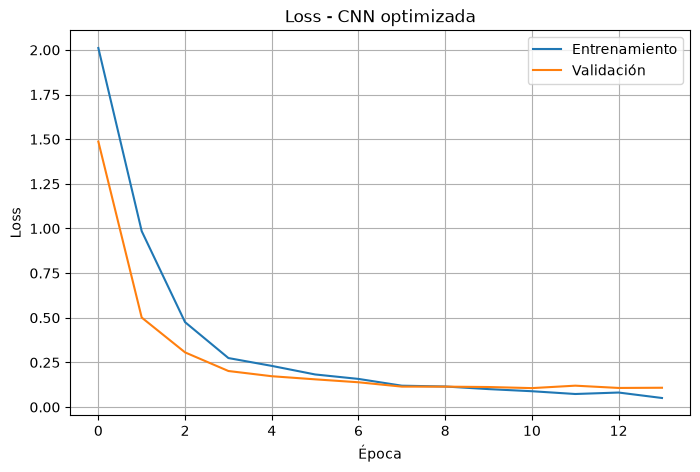

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    historial_optimizado.history["loss"],
    label="Entrenamiento")

plt.plot(
    historial_optimizado.history["val_loss"],
    label="Validación")

plt.title("Loss - CNN optimizada")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

### Comparación y reflexión sobre la optimización

El modelo CNN inicial obtuvo un **accuracy de 96,39 %** y un `loss` de **0,1034** sobre el conjunto de prueba.

Posteriormente, se aplicaron técnicas de optimización y regularización. Se modificaron hiperparámetros del entrenamiento, utilizando un máximo de 30 épocas y un `batch_size` de 16. Además, se incorporó una capa `Dropout` de 0,30 y se utilizó `EarlyStopping` para supervisar la pérdida de validación.

El modelo optimizado obtuvo un **accuracy de 97,22 %** y un `loss` de **0,0902** sobre el mismo conjunto de prueba. En comparación con el modelo inicial, el accuracy aumentó en aproximadamente **0,83 puntos porcentuales**, mientras que el valor de loss disminuyó.

Por otra parte, aunque se estableció un máximo de 30 épocas, `EarlyStopping` detuvo automáticamente el entrenamiento después de **14 épocas**, evitando continuar entrenando cuando la pérdida de validación dejó de mejorar. Debido a `restore_best_weights=True`, se conservaron los pesos correspondientes al mejor comportamiento observado durante el entrenamiento.

Los resultados muestran que las técnicas aplicadas tuvieron un impacto positivo. `Dropout` contribuyó a regularizar la red y reducir el riesgo de sobreajuste, mientras que `EarlyStopping` permitió controlar la duración del entrenamiento utilizando el desempeño de validación como criterio. El ajuste de los hiperparámetros también permitió explorar una configuración diferente a la utilizada en el modelo inicial.

En conclusión, el modelo optimizado presentó una mejor capacidad de generalización, ya que alcanzó un mayor accuracy y un menor loss sobre datos no utilizados durante el entrenamiento. Esto demuestra la importancia de evaluar y ajustar una red neuronal después de construir un modelo inicial.